# sc-GEM Analysis

In [6]:
import numpy as np
import seaborn as sns
from umap import UMAP
import pandas as pd
import json
import sys
import matplotlib.pyplot as plt

embedding_dir = f'./'

DATA = 'sc_GEM'


In [7]:
cell_embeddings = np.load(f'{embedding_dir}/mymodel_0.npy')
gene_embeddings = np.load(f'{embedding_dir}/mymodel_1.npy')
omics_embeddings = np.load(f'{embedding_dir}/mymodel_2.npy')


In [8]:
from hgnn.hypergraph import load_graph


hg = load_graph('./data/sc_GEM', load_edges=False)
cell_names = hg.cell_names
gene_names = hg.gene_names

load_edges=False
Load nodes in 0.00 seconds.
Num nodes: 287, Num edges: NaN
Metadata: {'dataname': 'sc_GEM', 'filter_edge': False, 'num_cells': 224, 'num_genes': 61, 'num_omics': 2, 'num_nodes': 287, 'orig_edges': 13664, 'num_edges': 13664, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 63, 'omics_dims': [59, 59], 'raw_data': {'expr': './data/sc_GEM/expression_data.csv', 'methy': './data/sc_GEM/methylation_data.csv'}, 'cell_key': 'Cell ID', 'normalize_stats': [], 'normalization': True, 'train_size': 0.8}


In [38]:
cell_stage = [name.split('_')[0] for name in cell_names]

In [39]:
cell_stage

['BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16

## Cell Embeddings

In [ ]:
# cell_stage = json.load(open('./data/sc_GEM/cell_stage.json'))

In [12]:
cell_stage

['BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd8',
 'd16T-',
 'd16T-',
 'd16T-',
 'd16T-',
 'd16T-',
 'd16T-',
 'd16T-',
 'd16T-',
 'd16T-',
 'd16T-',
 'd16T-',
 'd16T-',
 'd16T-',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd24T-',
 'd24T-',
 'd24

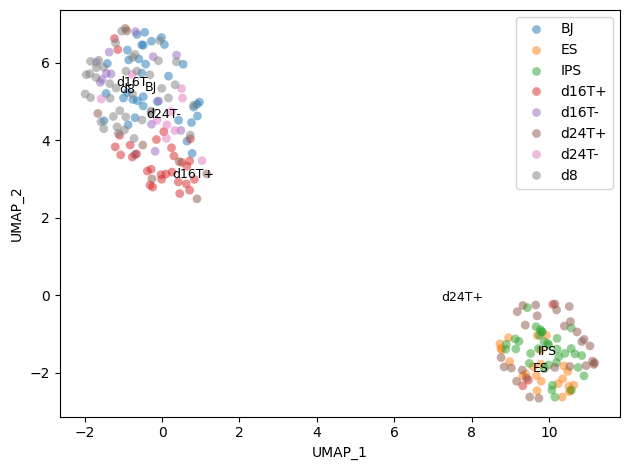

In [40]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

# plt.figure(figsize=(6,4))
vec = UMAP(n_components=2).fit_transform(cell_embeddings)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage,
                hue_order=sorted(set(cell_stage)),
                s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")

# ---- 计算每个类的中心并标注 ----
df = pd.DataFrame({'UMAP_1': vec[:, 0], 'UMAP_2': vec[:, 1], 'label': cell_stage})
centroids = df.groupby('label')[['UMAP_1', 'UMAP_2']].mean()

for label, row in centroids.iterrows():
    plt.text(row['UMAP_1'], row['UMAP_2'], str(label),
             fontsize=9, ha='center', va='center',)
plt.tight_layout()

ES, IPS, d24T+ are in one group.

Others are in the other group.

## Heatmaps of gene embeddings

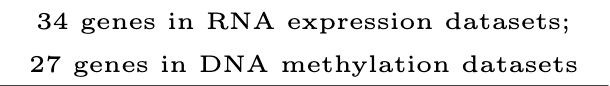

In [14]:
gene_embeddings.shape, len(gene_names)

((61, 64), 61)

In [15]:
df_gene = pd.DataFrame(gene_embeddings.T, columns=gene_names)
df_gene

Name,AFP_expr,BMP7_expr,CDH1_expr,CDX2_expr,CER1_expr,DAZL_expr,DNMT3B_expr,DNMT3L_expr,FGF4_expr,FOSL1_expr,...,NXRA8_methy,PIWIL1_methy,PLEKHH3_methy,STON2P1_methy,SULT1A1_methy,TFAP2A_methy,TMEM173_methy,TNNI3_methy,UNC45A_methy,ZNF662_methy
0,0.190173,1.489591,1.155509,-0.361362,-0.182115,0.056085,1.453474,0.300927,1.035743,0.948515,...,-0.009026,0.137272,0.206519,0.440782,0.023050,0.692397,0.392982,0.868070,0.223815,0.055511
1,-1.650293,-0.672803,-1.287558,-2.373091,-0.629106,-1.215321,-1.481426,-1.455670,-0.890589,0.475406,...,-0.133573,-0.473852,0.049996,-0.101463,-0.678690,-0.106229,-0.181016,-0.118979,0.053479,-0.364947
2,-0.796759,0.524594,0.358648,-1.507257,-0.405599,-0.755265,-0.580897,-0.357093,1.218069,-1.438694,...,-0.832831,-0.438493,-1.287927,-1.135826,-0.420057,-1.633603,-0.542786,-0.941209,-1.283000,-1.009064
3,0.315760,-1.304680,-1.562793,-0.356856,0.496309,0.098470,-1.171897,-0.276005,-0.642524,1.043800,...,-0.024549,-0.077618,0.794585,0.520332,-0.332963,0.681706,-0.258057,-0.194983,-0.179303,0.141325
4,0.883921,1.657769,1.188854,-0.058780,0.848652,0.726230,0.712452,-0.792952,0.653614,0.898184,...,1.221372,0.483168,0.813603,1.241531,0.629826,0.914521,1.185107,1.005760,0.873563,1.097619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,-2.218531,0.440904,0.687459,-1.340145,1.326777,-1.936221,1.092458,-0.226422,0.688789,1.295187,...,-1.272408,-1.712105,-1.363458,-1.565481,-1.920801,-1.212605,-1.608308,-1.346845,-1.756763,-1.892412
60,0.837522,-0.891188,-1.127849,0.975431,0.089367,0.890025,-1.441058,0.157460,-1.506861,-0.243362,...,-0.611116,-0.203941,-1.174055,-0.755573,-0.819438,-0.801003,-0.619431,-0.514369,-0.329303,-0.424877
61,0.731758,-0.151392,0.234303,1.118506,0.904568,1.167617,0.693299,0.535666,0.511781,0.208330,...,1.469331,1.376869,1.831347,1.403905,1.783109,1.731730,1.513555,1.733833,1.345665,1.658470
62,0.397134,-0.053041,0.447221,0.836235,-1.185803,0.613101,-0.239260,2.038617,0.213819,0.571935,...,0.125426,0.775807,0.213285,0.774936,0.376694,0.408644,0.438679,0.261959,0.310793,0.339552


In [16]:
EXPR_LIST = [
    "ZIC3", "KCNQ2", "ZFP42", "OTX2", "SALL4", "NANOG", "SOX2", "CDH1",
    "BMP7", "PRDM14", "DNMT3B", "TFCP2L1", "MMP9", "FGF4", "LEFTY",
    "WNT10B", "OCT4", "ZSCAN18", "CER1", "IGF2", "HAND1", "TFAP2A",
    "TBX3", "FOSL1", "LUM", "TGFBR2"
]
METHY_LIST = [
    "CDH22", "KCNQ2", "NXRA8", "DPPA3", "TMEM173", "COL20A1", "TNNI3",
    "CHL1", "STON2P1", "ALDH3A1", "UNC45A", "SULT1A1", "ZNF662", "LTBR",
    "PIWIL1", "CYBRD1", "FOXD2", "HLX-AS1", "ADAM33", "NFIX", "COL23A1",
    "LY86-AS1", "NFATC1", "PLEKHH3", "TFAP2A", "EPHB3", "AK123759"
]
len(EXPR_LIST), len(METHY_LIST)

(26, 27)

## Heatmap of RNA Expression

In [17]:
df_expr = df_gene.loc[:, df_gene.columns.str.endswith('_expr')].rename(lambda x: x.replace('_expr', ''), axis=1)
df_expr = df_expr.loc[:, EXPR_LIST]

Text(0.5, 1.0, 'Pearson correlations heatmap of RNA expression on sc-GEM')

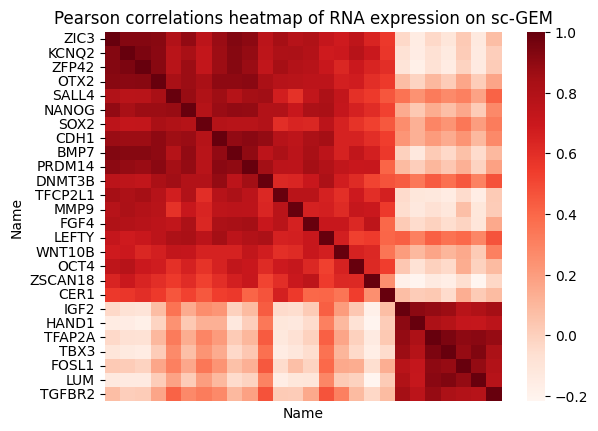

In [18]:
sns.heatmap(df_expr.corr(method='pearson'), cmap='Reds', yticklabels=EXPR_LIST)
plt.xticks([])
plt.title('Pearson correlations heatmap of RNA expression on sc-GEM')

## Heatmap of DNA Methylation

In [19]:
df_methy = df_gene.loc[:, df_gene.columns.str.endswith('_methy')].rename(lambda x: x.replace('_methy', ''), axis=1)
df_methy = df_methy.loc[:, METHY_LIST]

Text(0.5, 1.0, 'Pearson correlations heatmap of DNA methylation on sc-GEM')

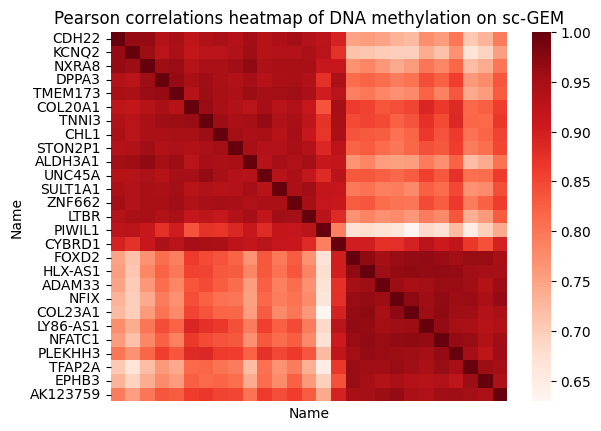

In [20]:
sns.heatmap(df_methy.corr(method='pearson'), cmap='Reds', yticklabels=METHY_LIST)
plt.xticks([])
plt.title('Pearson correlations heatmap of DNA methylation on sc-GEM')

## Projection of pluripotency and somatic gene embeddings

In [21]:
pluripotency = ["ZIC3", "KCNQ2", "ZFP42", "OTX2", "SALL4", "NANOG", "SOX2", "CDH1",
    "BMP7", "PRDM14", "DNMT3B", "TFCP2L1", "MMP9", "FGF4", "LEFTY",
    "WNT10B", "OCT4", "ZSCAN18", "CER1",]

intermedia = [
     'IGF2',
    'HAND1',
]

somatic = [
     'TFAP2A',
     'TBX3',
     'FOSL1',
     'LUM',
     'TGFBR2'
]

In [22]:
pluripotency_gene_df = df_expr.loc[:, pluripotency]
somatic_gene_df = df_expr.loc[:, somatic]

In [23]:
cell_norms = np.linalg.norm(cell_embeddings, axis=1).reshape((-1, 1))
cell_df = pd.DataFrame(cell_embeddings / cell_norms, index=cell_names)


In [24]:
np.sum(cell_df.iloc[0, :].values ** 2) # Cell embeddings normalized.

1.0

In [25]:
special_cell_stages = ['BJ', 'd8', 'd16', 'd24', 'IPS', 'ES']
special_cell_ids = [x for x in cell_df.index if any(stage in x for stage in special_cell_stages)]

In [26]:
special_cells_df = cell_df.loc[special_cell_ids, :].reset_index(names='cell_id')

In [27]:
def find_stage(cell_id):
    for stage in special_cell_stages:
        if stage in cell_id:
            return stage
    return '??'

special_cells_df['stage'] = special_cells_df['cell_id'].apply(find_stage)
special_cells_df = special_cells_df.drop(columns='cell_id').set_index('stage')

### Somatic projection

In [28]:
proj_somatic = (special_cells_df @ somatic_gene_df)
proj_somatic = pd.melt(proj_somatic.reset_index(), id_vars='stage')
proj_somatic


,stage,Name,value
0,BJ,TFAP2A,-0.949492
1,BJ,TFAP2A,0.543350
2,BJ,TFAP2A,0.532546
3,BJ,TFAP2A,-0.752946
4,BJ,TFAP2A,-0.610818
...,...,...,...
1115,d8,TGFBR2,-0.443538
1116,d8,TGFBR2,-0.279032
1117,d8,TGFBR2,-0.299716
1118,d8,TGFBR2,-0.772295


Text(0, 0.5, 'Projection value')

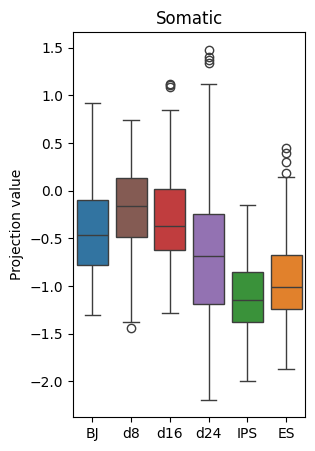

In [29]:
plt.figure(figsize=(3,5))
sns.boxplot(proj_somatic, x='stage', y='value', order=special_cell_stages, hue='stage')
plt.title('Somatic')
plt.xlabel('')
plt.ylabel('Projection value')


### Pluripotency projection

In [30]:
proj_pluripotency = (special_cells_df @ pluripotency_gene_df)
proj_pluripotency = pd.melt(proj_pluripotency.reset_index(), id_vars='stage')
proj_pluripotency


,stage,Name,value
0,BJ,ZIC3,-0.063569
1,BJ,ZIC3,0.144511
2,BJ,ZIC3,0.167912
3,BJ,ZIC3,-1.526255
4,BJ,ZIC3,-0.072944
...,...,...,...
4251,d8,CER1,-0.028625
4252,d8,CER1,0.343078
4253,d8,CER1,-0.188911
4254,d8,CER1,0.091481


Text(0, 0.5, 'Projection value')

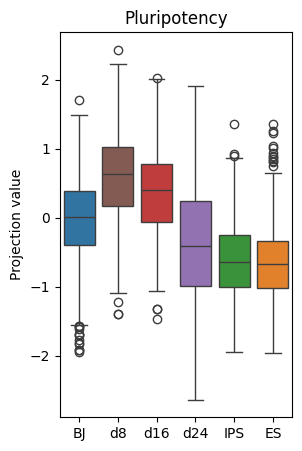

In [31]:
plt.figure(figsize=(3,5))
sns.boxplot(proj_pluripotency, x='stage', y='value', order=special_cell_stages, hue='stage')
plt.title('Pluripotency')
plt.xlabel('')
plt.ylabel('Projection value')

## Cell Clustering

In [32]:
cell_stage_unique = sorted(set(cell_stage))
num_clusters = len(cell_stage_unique)
# Convert str to label id.
cell_stage_ids = {lbl : i for i, lbl in enumerate(cell_stage_unique)}
cell_stage_label = np.array([cell_stage_ids[y] for y in
                             cell_stage])

print(cell_stage_unique)
print('num_clusters', num_clusters)
print(cell_stage_ids)
print(np.min(cell_stage_label), np.max(cell_stage_label))

['BJ', 'ES', 'IPS', 'd16T+', 'd16T-', 'd24T+', 'd24T-', 'd8']
num_clusters 8
{'BJ': 0, 'ES': 1, 'IPS': 2, 'd16T+': 3, 'd16T-': 4, 'd24T+': 5, 'd24T-': 6, 'd8': 7}
0 7


In [33]:
from scoit.cell_analysis import cluster_evaluate

cluster_evaluate(cell_embeddings, cell_stage)

{'NMI': 0.3161267110367156,
 'ARI': 0.17933532538707544,
 'FMI': 0.310589611291004}

### Baselines

t-SNE, PCA, UMAP.

In [34]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

from scoit.cell_analysis import RunLeiden, RunLouvain, knn_adj_matrix

In [35]:
from hgnn.hypergraph import HyperGraphCreator
from pathlib import Path

create = HyperGraphCreator({
        'expr': './data/sc_GEM/expression_data.csv',
        'methy': './data/sc_GEM/methylation_data.csv',
    }, cell_key='Cell ID', dataname='sc_GEM', prefix=Path('./data'))

In [36]:
create.load_and_preprocess_data()

Begin to load multi omics data {'expr': './data/sc_GEM/expression_data.csv', 'methy': './data/sc_GEM/methylation_data.csv'}
Load data done, time: 0.009069681167602539
Rename columns
Name: expr, Columns: Index(['ADAM33_expr', 'AFP_expr', 'AK123759_expr', 'ALDH3A1_expr', 'BMP7_expr',
       'CDH1_expr', 'CDH22_expr', 'CDX2_expr', 'CER1_expr', 'CHL1_expr',
       'COL20A1_expr', 'COL23A1_expr', 'CYBRD1_expr', 'DAZL_expr',
       'DNMT3B_expr', 'DNMT3L_expr', 'DPPA3_expr', 'EPHB3_expr', 'FGF4_expr',
       'FOSL1_expr', 'FOXD2_expr', 'HAND1_expr', 'HLX-AS1_expr', 'IGF2_expr',
       'JARID2_expr', 'KCNQ2_expr', 'LEFTY_expr', 'LTBR_expr', 'LUM_expr',
       'LY86-AS1_expr', 'MMP9_expr', 'MYC_expr', 'NANOG_expr', 'NESTIN_expr',
       'NFATC1_expr', 'NFIX_expr', 'NKX2-5_expr', 'NXRA8_expr', 'OCT4_expr',
       'OTX2_expr', 'PIWIL1_expr', 'PLEKHH3_expr', 'PRDM14_expr', 'SALL4_expr',
       'SOX2_expr', 'STON2P1_expr', 'SULT1A1_expr', 'TBX3_expr', 'TFAP2A_expr',
       'TFCP2L1_expr', 'TGFBR2_

In [37]:
assert (create.df.index == cell_names).all().all()


AssertionError: 

In [ ]:
features = create.df.values
features.shape

(224, 61)